# TFT experiment - Walmart Store Sales Forecasting

Person B track (DL + Prophet). Third of the four notebooks in this track,
after `model_experiment_dlinear.ipynb` and `model_experiment_nbeats.ipynb`,
which already prove out the shared darts harness (panel build -> fit ->
backtest -> MLflow -> `.predict()` wrapper). TFT reuses that harness and adds
what DLinear/N-BEATS don't have: **static covariates** (`Type`, `Size`,
`Store`, `Dept` learned as categorical embeddings) and **probabilistic
(quantile) forecasting**.

**Decisions this notebook records for the README:**
- future vs past covariate split - reused as-is from the DLinear/N-BEATS EDA
  finding (checked once against `features.csv` coverage, not re-derived here).
- static covariate scope - full richness (`Type` + `Size` + `Store` + `Dept`
  embeddings), the deliberate choice for this notebook since static metadata
  is TFT's main architectural advantage over the other two DL models.
- quantile likelihood (`QuantileRegression([0.1, 0.5, 0.9])`) - the median
  (`q0.5`) is used as the point forecast for WMAE/submission, the 10-90% band
  is used for interval plots.
- validation strategy - same expanding-window CV (`src/validation.py`,
  3 folds x 13 weeks) as every other model in the project, so WMAE is
  directly comparable.
- no early stopping during CV/HP-search fits - structural, not an oversight:
  each fold's validation window (13 weeks) is shorter than
  `input_chunk_length + output_chunk_length` (91 weeks), the minimum darts
  needs to form even one internal validation sample. This is the same
  limitation the DLinear notebook already ran into and documented. Real
  out-of-sample scoring instead happens via `.predict()` + `weighted_mae`
  against each fold's held-out actuals, same as DLinear/N-BEATS.

**MLflow run plan** (8 runs total under `TFT_Training` - richer than DLinear/
N-BEATS's 3, matching ARIMA's 6): `TFT_Feature_Selection`, three
`TFT_HP_*` architecture-comparison runs, three `TFT_CV_Fold*` runs, and
`TFT_Final`.


##  Init cell (Colab-compatible)

Byte-identical to the DLinear/N-BEATS notebooks' init cell, itself derived
from `notebooks/EDA.ipynb`'s first cell plus a `darts[torch]` install -
keeping all three DL notebooks' bootstrap in sync.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

IS_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if IS_COLAB:
    REPO_URL = "https://github.com/NikaMikeltadze/walmart-sales-forecasting.git"
    REPO_DIR = "/content/walmart-sales-forecasting"

    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r",
         f"{REPO_DIR}/requirements.txt", "--quiet"],
        check=True,
    )
    subprocess.run([sys.executable, "-m", "pip", "install", "darts[torch]", "--quiet"], check=True)

    os.chdir(f"{REPO_DIR}/notebooks")

    from google.colab import drive
    drive.mount("/content/drive")

    drive_data_dir = Path("/content/drive/MyDrive/walmart-sales-forecasting/data/raw")
    repo_data_dir = Path(REPO_DIR) / "data" / "raw"
    if drive_data_dir.exists():
        subprocess.run(["cp", "-r", f"{drive_data_dir}/.", str(repo_data_dir)], check=True)
    else:
        raise FileNotFoundError(
            f"Expected Drive data folder not found at {drive_data_dir}. "
            "Create it (or add it as a My Drive shortcut) before running this notebook."
        )

sys.path.append(str(Path.cwd().parent))


Mounted at /content/drive


##  Imports

In [2]:
import pickle
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from sklearn.preprocessing import StandardScaler

from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler
from darts.utils.likelihood_models import QuantileRegression
from darts.explainability import TFTExplainer

from pytorch_lightning.loggers import CSVLogger

from src.preprocessing import load_raw_data, WalmartPreprocessor
from src.features import add_temporal_features
from src.evaluation import weighted_mae

pd.set_option("display.max_columns", 50)
pd.set_option("future.no_silent_downcasting", True)


###  Manual credentials override (VS Code / non-Colab-UI runtimes)

`google.colab.userdata` (Colab Secrets) can only be read from the Colab
**browser UI**. When the Colab runtime is driven from VS Code or any other
non-UI frontend it times out (`Secrets can only be fetched when running from
the Colab UI`). This cell sets the DagsHub creds directly instead, and the
credentials cell below skips `userdata` whenever these env vars are already
set.

`getpass` is used so the token is never written into this committed notebook -
run the cell and paste the values when prompted. Leave a prompt blank to fall
through to Colab Secrets / `.env` below (e.g. when you *are* on the Colab UI).

In [3]:
import os
from getpass import getpass

# Only prompt for values not already set, so re-running cells doesn't re-ask.
# Leave a prompt blank to fall through to Colab Secrets / .env in the next cell.
if not os.environ.get("MLFLOW_TRACKING_USERNAME"):
    _user = getpass("DagsHub username (blank -> use Colab Secrets / .env): ").strip()
    if _user:
        os.environ["MLFLOW_TRACKING_USERNAME"] = _user
if not os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    _token = getpass("DagsHub token (blank -> use Colab Secrets / .env): ").strip()
    if _token:
        os.environ["MLFLOW_TRACKING_PASSWORD"] = _token


##  Load DagsHub credentials

`MLFLOW_TRACKING_USERNAME`/`MLFLOW_TRACKING_PASSWORD` are never hardcoded in
this notebook (it gets committed to the shared repo, so a hardcoded token
would leak).

- On the Colab UI: read from Colab secrets - add `DAGSHUB_USERNAME` and
  `DAGSHUB_TOKEN` via the key icon in the left sidebar, and enable
  "Notebook access" for both. Same approach as every other notebook.
- From VS Code / non-UI runtimes: use the manual-override cell above.
- Locally: falls back to a gitignored `.env` in the repo root.

In [4]:
if os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"):
    # Already provided (e.g. by the manual-override cell above when driving the
    # Colab runtime from VS Code, where google.colab.userdata would time out).
    # Note: userdata.get(...) must NOT be evaluated in this case - it blocks for
    # ~minutes and raises when there is no Colab browser UI to answer it.
    creds_source = "pre-set environment variables"
elif IS_COLAB:
    from google.colab import userdata

    os.environ["MLFLOW_TRACKING_USERNAME"] = userdata.get("DAGSHUB_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = userdata.get("DAGSHUB_TOKEN")
    creds_source = "Colab secrets (DAGSHUB_USERNAME / DAGSHUB_TOKEN)"
else:
    from dotenv import load_dotenv

    env_path = Path.cwd().parent / ".env"
    load_dotenv(env_path)
    creds_source = str(env_path)

assert os.environ.get("MLFLOW_TRACKING_USERNAME") and os.environ.get("MLFLOW_TRACKING_PASSWORD"), (
    f"MLFLOW_TRACKING_USERNAME/PASSWORD not set (tried: {creds_source}). "
    "On the Colab UI: add DAGSHUB_USERNAME and DAGSHUB_TOKEN as Colab secrets "
    "(key icon in the left sidebar) and enable notebook access for both. "
    "From VS Code / non-UI runtimes: run the manual-override cell above. "
    "Locally: create a .env in the repo root with MLFLOW_TRACKING_USERNAME=... "
    "and MLFLOW_TRACKING_PASSWORD=..."
)
print("MLflow credentials loaded from:", creds_source)


MLflow credentials loaded from: pre-set environment variables


##  MLflow tracking store

Shared DagsHub MLflow server - the single source of truth for cross-model
WMAE comparison and the Model Registry, so all 7 models (both tracks) log
here rather than to a per-notebook local store. Does not silently fall back
to a local store if auth fails - that would desync TFT's runs from the rest
of the team's.

In [5]:
MLFLOW_TRACKING_URI = "https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

try:
    mlflow.set_experiment("TFT_Training")
    mlflow.MlflowClient().search_experiments(max_results=1)  # force a network round trip now
except Exception as e:
    raise RuntimeError(
        "Could not authenticate to the DagsHub MLflow server at "
        f"{MLFLOW_TRACKING_URI}. Set MLFLOW_TRACKING_USERNAME and "
        "MLFLOW_TRACKING_PASSWORD (a DagsHub access token) as environment "
        "variables, then re-run this cell. Not falling back to local "
        "./mlruns or sqlite - that would desync from Person A's XGBoost/"
        "LightGBM runs and the rest of the team's runs."
    ) from e

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("TFT_Training").name)


MLflow tracking URI: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow
Active experiment: TFT_Training


##  Load, merge, clean

Reuses `load_raw_data` / `WalmartPreprocessor` rather than reimplementing
loading logic (per `CLAUDE.md`). `WalmartPreprocessor.fit()` loads and caches
`features_` / `stores_` internally - `stores_` (Store, Type, Size) is what
the static-covariate section below builds on.

In [6]:
raw_data = load_raw_data(data_dir="../data/raw")

train_raw = raw_data["train"]
test_raw = raw_data["test"]

preprocessor = WalmartPreprocessor(data_dir="../data/raw")
preprocessor.fit(train_raw)

train_clean = preprocessor.transform(train_raw)
test_clean = preprocessor.transform(test_raw)

train_feat = add_temporal_features(train_clean)
test_feat = add_temporal_features(test_clean)

print(train_feat.shape, test_feat.shape)
train_feat.head()


(421570, 23) (115064, 22)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,week_of_year,month,year,days_to_super_bowl,days_to_labor_day,days_to_thanksgiving,days_to_christmas
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,2,2010,7,217,294,329
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,2,2010,0,210,287,322
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,2,2010,-7,203,280,315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,8,2,2010,-14,196,273,308
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,3,2010,-21,189,266,301


##  Covariate coverage decision

Same check already established in the DLinear/N-BEATS notebooks - reused
here rather than re-derived, since it's a property of `features.csv`, not of
the model. A column only becomes a *future* covariate if it's non-null for
every week of the test horizon (2012-11-02 to 2013-07-26).

In [7]:
test_dates = pd.date_range("2012-11-02", "2013-07-26", freq="W-FRI")

macro_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment",
              "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

features_lookup = preprocessor.features_

coverage = {}
for col in macro_cols:
    non_null_dates = set(features_lookup.loc[features_lookup[col].notna(), "Date"])
    coverage[col] = set(test_dates).issubset(non_null_dates)

coverage_df = pd.Series(coverage, name="covers_full_test_range")
print(coverage_df)

calendar_future_cols = ["IsHoliday", "week_of_year", "month", "year",
                         "days_to_super_bowl", "days_to_labor_day",
                         "days_to_thanksgiving", "days_to_christmas"]

FUTURE_COVARIATE_COLS = calendar_future_cols + [c for c in coverage_df.index if coverage_df[c]]
PAST_COVARIATE_COLS = [c for c in coverage_df.index if not coverage_df[c]]
all_covariate_cols = FUTURE_COVARIATE_COLS + PAST_COVARIATE_COLS

print("Future covariates:", FUTURE_COVARIATE_COLS)
print("Past covariates:", PAST_COVARIATE_COLS)


Temperature      True
Fuel_Price       True
CPI              True
Unemployment     True
MarkDown1        True
MarkDown2       False
MarkDown3        True
MarkDown4        True
MarkDown5        True
Name: covers_full_test_range, dtype: bool
Future covariates: ['IsHoliday', 'week_of_year', 'month', 'year', 'days_to_super_bowl', 'days_to_labor_day', 'days_to_thanksgiving', 'days_to_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Past covariates: ['MarkDown2']


##  Static covariates (TFT-only - the main architectural advantage over DLinear/N-BEATS)

Neither DLinear nor N-BEATS in this project's installed darts version uses
static (per-series) metadata. TFT does, and this is deliberately the richer
option: `Type` and `Store`/`Dept` identity get **learned categorical
embeddings** (`TFTModel(categorical_embedding_sizes=...)`), `Size` is a
scaled continuous static covariate.

`TorchForecastingModel`s only accept numeric static covariate columns, so
categoricals are integer-coded here rather than left as strings/categories.
`Store`/`Dept` ids are remapped to contiguous `0..n-1` codes (not used
directly as embedding indices) since raw `Dept` ids have gaps - an
`nn.Embedding` lookup would otherwise index out of range. One extra "unknown"
embedding bucket is reserved for both, a cheap safety margin in case the
`.predict()` wrapper (see below) ever sees a `Store`/`Dept` combination
outside what's been seen here.

In [8]:
STORE_IDS = sorted(pd.concat([train_feat["Store"], test_feat["Store"]]).unique())
DEPT_IDS = sorted(pd.concat([train_feat["Dept"], test_feat["Dept"]]).unique())
store_code_map = {store: i for i, store in enumerate(STORE_IDS)}
dept_code_map = {dept: i for i, dept in enumerate(DEPT_IDS)}
type_code_map = {"A": 0, "B": 1, "C": 2}

stores_df = preprocessor.stores_.copy()
stores_df["Type_Code"] = stores_df["Type"].astype(str).map(type_code_map).astype(float)

size_scaler = StandardScaler()
stores_df["Size_Scaled"] = size_scaler.fit_transform(stores_df[["Size"]]).astype(float)

store_static_lookup = stores_df.set_index("Store")[["Type_Code", "Size_Scaled"]].to_dict("index")

UNKNOWN_STORE_CODE = float(len(STORE_IDS))
UNKNOWN_DEPT_CODE = float(len(DEPT_IDS))


def make_static_covariates_df(store, dept):
    """One-row static covariate frame for a single (Store, Dept) series."""
    info = store_static_lookup[store]
    return pd.DataFrame({
        "Type_Code": [info["Type_Code"]],
        "Size_Scaled": [info["Size_Scaled"]],
        "Store_Code": [float(store_code_map.get(store, UNKNOWN_STORE_CODE))],
        "Dept_Code": [float(dept_code_map.get(dept, UNKNOWN_DEPT_CODE))],
    })


def attach_static_covariates(series_list, keys):
    """Attach the matching static-covariate row to each per-(Store, Dept) TimeSeries."""
    return [
        ts.with_static_covariates(make_static_covariates_df(store, dept))
        for ts, (store, dept) in zip(series_list, keys)
    ]


CATEGORICAL_EMBEDDING_SIZES = {
    "Type_Code": (len(type_code_map), 2),
    "Store_Code": (len(STORE_IDS) + 1, 8),
    "Dept_Code": (len(DEPT_IDS) + 1, 8),
}

print("Static covariates: Type_Code, Size_Scaled, Store_Code, Dept_Code")
print("Categorical embedding sizes:", CATEGORICAL_EMBEDDING_SIZES)


Static covariates: Type_Code, Size_Scaled, Store_Code, Dept_Code
Categorical embedding sizes: {'Type_Code': (3, 2), 'Store_Code': (46, 8), 'Dept_Code': (82, 8)}


##  Model definition and covariate/static support check

Check what the *installed* darts version's `TFTModel` actually accepts
before assuming API shape - this has changed across darts releases. TFT is
the only one of the three DL models in this project that supports past,
future, **and** static covariates simultaneously - that's the whole reason
it's worth the extra training cost over DLinear/N-BEATS.

**Runtime budget (kept deliberately tight - TFT is the heaviest model in this
project and there's a real GPU-time budget):** without a cap, one epoch over
~3,000 series x ~150 weeks of history each would iterate over every possible
overlapping (input, output) window per series - tens of thousands of training
samples per epoch, on top of the LSTM+attention cost per batch. `max_samples_per_ts`
below bounds the number of windows drawn per series each epoch to a fixed
ceiling regardless of a series' history length, which makes epoch time roughly
constant and predictable instead of scaling with total history. Larger batch
sizes than the DLinear/N-BEATS notebooks (256/512 vs 128/256) trade a few more
steps of gradient noise for meaningfully fewer, better-utilized GPU steps per
epoch. Quantile sampling at predict time is capped at 50 samples (`NUM_SAMPLES_PREDICT`)
rather than 100 - still plenty stable for a median (`q0.5`) point estimate.

In [9]:
import torch

FREQ = "W-FRI"
inferred_freq = pd.infer_freq(sorted(train_feat["Date"].unique()))
print("Inferred frequency from data:", inferred_freq)
assert inferred_freq in ("W-FRI", None), f"Unexpected frequency: {inferred_freq}"

INPUT_CHUNK_LENGTH = 52   # one year of history
OUTPUT_CHUNK_LENGTH = 39  # covers the full test horizon - test is ~39 weeks past train
MIN_REQUIRED_LENGTH = INPUT_CHUNK_LENGTH + OUTPUT_CHUNK_LENGTH  # darts needs this much history per training series

# Epoch ceilings - cut hard a second time after a real run showed this was still too
# slow for the available compute budget (a live GPU session ran at ~1.43 it/s, in line
# with this notebook's own CPU benchmark rather than healthy GPU throughput - check the
# trainer startup log for "GPu available: True (cuda), used: True"; if it says False,
# no amount of shrinking these numbers fixes that, reconnect to an actual GPU runtime).
HP_N_EPOCHS = 2      # ceiling for the quick 3-way architecture comparison
CV_N_EPOCHS = 4      # ceiling per CV fold
FINAL_N_EPOCHS = 8   # ceiling for the single final fit on full history

# max_samples_per_ts bounds training windows drawn per series each epoch, so
# epoch time stays roughly constant regardless of any one series' history length
# (without this, darts uses every overlapping window - unbounded and the single
# biggest runtime risk in this notebook). Final gets a slightly bigger budget
# since it's the model that actually ships.
MAX_SAMPLES_PER_TS_HP = 10
MAX_SAMPLES_PER_TS_CV = 15
MAX_SAMPLES_PER_TS_FINAL = 25

BATCH_SIZE_SEARCH = 384  # HP search + CV folds
BATCH_SIZE_FINAL = 512   # fewer, better-GPU-utilized steps for the final fit

NUM_SAMPLES_PREDICT = 25  # quantile-sampling draws at predict() time (was 100 - q0.5 is stable well below that)

QUANTILES = [0.1, 0.5, 0.9]

TFT_ARCH_KWARGS = dict(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    categorical_embedding_sizes=CATEGORICAL_EMBEDDING_SIZES,
    likelihood=QuantileRegression(quantiles=QUANTILES),
    random_state=42,
)


def make_accelerator_kwargs(logger=None, callbacks=None):
    """pl_trainer_kwargs shared by every fit call below, so GPU selection is consistent."""
    backend = "gpu" if torch.cuda.is_available() else "cpu"
    kwargs = {"accelerator": backend, "callbacks": callbacks or []}
    if logger is not None:
        kwargs["logger"] = logger
    if backend == "gpu":
        kwargs["devices"] = 1
    return kwargs


# Throwaway, unfit instance just to introspect covariate/static support - cheap (no .fit() call).
_support_probe = TFTModel(n_epochs=1, batch_size=32, **TFT_ARCH_KWARGS)
SUPPORTS_PAST = _support_probe.supports_past_covariates
SUPPORTS_FUTURE = _support_probe.supports_future_covariates
SUPPORTS_STATIC = _support_probe.supports_static_covariates

print("Supports past covariates:", SUPPORTS_PAST)
print("Supports future covariates:", SUPPORTS_FUTURE)
print("Supports static covariates:", SUPPORTS_STATIC)

TFT_FUTURE_COLS = FUTURE_COVARIATE_COLS if SUPPORTS_FUTURE else []
TFT_PAST_COLS = PAST_COVARIATE_COLS if SUPPORTS_PAST else (PAST_COVARIATE_COLS + FUTURE_COVARIATE_COLS)

print("Columns fed as past_covariates:", TFT_PAST_COLS)
print("Columns fed as future_covariates:", TFT_FUTURE_COLS)
assert SUPPORTS_STATIC, "TFTModel in the installed darts version no longer supports static covariates - re-check this section"


Inferred frequency from data: W-FRI
Supports past covariates: True
Supports future covariates: True
Supports static covariates: True
Columns fed as past_covariates: ['MarkDown2']
Columns fed as future_covariates: ['IsHoliday', 'week_of_year', 'month', 'year', 'days_to_super_bowl', 'days_to_labor_day', 'days_to_thanksgiving', 'days_to_christmas', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MarkDown1', 'MarkDown3', 'MarkDown4', 'MarkDown5']


##  Build the darts panel (gap-interpolated target, store-level covariates, static covariates attached)

Same panel-building helpers as DLinear/N-BEATS (`build_darts_series`,
`build_store_level_covariates`, `split_past_future`), plus
`attach_static_covariates` from the section above. Target gaps get linearly
interpolated (interior missing weeks, not 0-sales weeks); covariates are
built once per Store, spanning train+test, immune to any single
department's short test presence.

In [10]:
def build_darts_series(df, value_col="Weekly_Sales", covariate_cols=None, freq=FREQ):
    """
    Convert a long-format (Store, Dept, Date, ...) frame into darts TimeSeries,
    one per (Store, Dept). Target gaps are linearly interpolated (genuine
    missing weeks, not 0-sales weeks). Covariate gaps are ffill/bfill'd.
    """
    covariate_cols = covariate_cols or []
    series_list, covariate_series_list, keys = [], [], []

    for (store, dept), g in df.groupby(["Store", "Dept"]):
        g = g.sort_values("Date")
        full_range = pd.date_range(g["Date"].min(), g["Date"].max(), freq=freq)
        g = g.set_index("Date").reindex(full_range)
        g.index.name = "Date"

        if value_col in g.columns:
            filled = g[value_col].interpolate(method="linear", limit_direction="both")
            series_list.append(TimeSeries.from_series(filled, freq=freq))

        if covariate_cols:
            cov = g[covariate_cols].ffill().bfill()
            covariate_series_list.append(TimeSeries.from_dataframe(cov, freq=freq))

        keys.append((store, dept))

    return series_list, (covariate_series_list or None), keys


def build_store_level_covariates(df, covariate_cols, global_start, global_end, freq=FREQ):
    """One covariate TimeSeries per Store (covariates don't vary by Dept),
    spanning the full global range so it's always long enough for any
    forecast horizon regardless of any single Dept's data gaps."""
    store_level = df.drop_duplicates(subset=["Store", "Date"])[["Store", "Date"] + covariate_cols]
    store_cov = {}
    for store, g in store_level.groupby("Store"):
        g = g.sort_values("Date").set_index("Date")
        full_range = pd.date_range(global_start, global_end, freq=freq)
        g = g.reindex(full_range)
        g.index.name = "Date"
        g[covariate_cols] = g[covariate_cols].ffill().bfill()
        store_cov[store] = TimeSeries.from_dataframe(g[covariate_cols], freq=freq)
    return store_cov


def split_past_future(cov_list, future_cols, past_cols):
    future_list = [ts[future_cols] for ts in cov_list] if future_cols else None
    past_list = [ts[past_cols] for ts in cov_list] if past_cols else None
    return past_list, future_list


target_series_raw, _, series_keys = build_darts_series(train_feat, covariate_cols=[], freq=FREQ)
target_series = attach_static_covariates(target_series_raw, series_keys)
print(f"Built {len(target_series)} target series for {len(series_keys)} (Store, Dept) pairs, static covariates attached.")

full_feat_df = pd.concat([train_feat, test_feat], ignore_index=True).drop_duplicates(
    subset=["Store", "Dept", "Date"]
)
numeric_cols = [c for c in all_covariate_cols if c not in ["Store", "Dept", "Date"]]
df_scaler = StandardScaler()
train_dates = train_feat["Date"].unique()
df_scaler.fit(full_feat_df.loc[full_feat_df["Date"].isin(train_dates), numeric_cols])
full_feat_scaled_df = full_feat_df.copy()
full_feat_scaled_df[numeric_cols] = df_scaler.transform(full_feat_df[numeric_cols])

GLOBAL_START = full_feat_scaled_df["Date"].min()
GLOBAL_END = full_feat_scaled_df["Date"].max()
print(f"Covariates span {GLOBAL_START} -> {GLOBAL_END}")

store_cov_series = build_store_level_covariates(
    full_feat_scaled_df, all_covariate_cols, GLOBAL_START, GLOBAL_END, freq=FREQ
)


Built 3331 target series for 3331 (Store, Dept) pairs, static covariates attached.
Covariates span 2010-02-05 00:00:00 -> 2013-07-26 00:00:00


## Time-based CV: expanding-window splits

Uses the real shared `src/validation.py` splitter (`expanding_window_splits`)
- same one every other model in the project uses. **Deliberately reduced to a
single fold here** (vs. the 3 folds DLinear/N-BEATS/XGBoost use) after a real
run showed TFT's per-epoch cost made 3 folds impractical within the available
compute budget - a documented, compute-driven scope reduction (same spirit as
CLAUDE.md's "don't over-invest training time" note for ARIMA), not an oversight.
This means TFT's WMAE here is a single-fold number, not a mean +/- std across
folds like the other models - flag that difference explicitly in the README
rather than presenting it as directly equivalent. Bump `N_SPLITS` back to 3
if/when more compute is available.

In [11]:
from src.validation import expanding_window_splits, split_series, describe_split

N_SPLITS = 1  # reduced from 3 - see markdown above for why
VAL_WEEKS = 13
MIN_TRAIN_WEEKS = 52

splits = expanding_window_splits(
    train_feat["Date"], n_splits=N_SPLITS, val_weeks=VAL_WEEKS, min_train_weeks=MIN_TRAIN_WEEKS
)
assert len(splits) == N_SPLITS, "history too short for the requested number of folds"

for i, split in enumerate(splits):
    print(f"fold {i}:", describe_split(split))


fold 0: {'train_start': 'start_of_history', 'train_end': '2012-07-27 00:00:00', 'val_start': '2012-08-03 00:00:00', 'val_end': '2012-10-26 00:00:00', 'val_weeks': 13, 'n_holidays_in_val': 1}


##  Log covariate/static-covariate decisions (`TFT_Feature_Selection`)

Lightweight run - just records the covariate split, static-covariate scope,
and architecture chosen above as params. No model fit happens here (actual
training happens in the HP-search, CV, and Final stages below).

In [12]:
with mlflow.start_run(run_name="TFT_Feature_Selection"):
    mlflow.log_params({
        "future_covariates": ",".join(TFT_FUTURE_COLS) if TFT_FUTURE_COLS else "none",
        "past_covariates": ",".join(TFT_PAST_COLS),
        "static_covariates": "Type_Code,Size_Scaled,Store_Code,Dept_Code",
        "static_covariate_scope": "full (Type + Size + Store + Dept embeddings)",
        "categorical_embedding_sizes": str(CATEGORICAL_EMBEDDING_SIZES),
        "supports_past_covariates": SUPPORTS_PAST,
        "supports_future_covariates": SUPPORTS_FUTURE,
        "supports_static_covariates": SUPPORTS_STATIC,
        "likelihood": f"QuantileRegression({QUANTILES})",
        "scaling": "StandardScaler (covariates + Size, fit on train only) + darts Scaler (target, per-series)",
        "target_gap_fill": "linear_interpolation (interior gaps only - genuine 0-sales weeks are untouched)",
        "covariate_gap_fill": "ffill/bfill, built once per Store (covariates are Dept-invariant)",
        "n_series_total": len(target_series),
        "min_required_length": MIN_REQUIRED_LENGTH,
        **{k: v for k, v in TFT_ARCH_KWARGS.items() if k not in ("likelihood", "categorical_embedding_sizes")},
    })

print("Logged TFT_Feature_Selection.")


🏃 View run TFT_Feature_Selection at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6/runs/6d33638ef6c749eaa5cb0d649fd71f4a
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6
Logged TFT_Feature_Selection.


##  Shared helper: build one CV fold's series

Used by both the hyperparameter comparison below and the full CV loop, so
the exact same fold-construction logic backs both.

In [13]:
def flatten_series(series_list, keys, value_name):
    rows = []
    for (store, dept), ts in zip(keys, series_list):
        df = ts.to_dataframe().reset_index()
        df.columns = ["Date", value_name]
        df["Store"] = store
        df["Dept"] = dept
        rows.append(df)
    return pd.concat(rows, ignore_index=True)


def build_fold_series(split, min_train_len):
    """Per-series train/val TimeSeries for one CV fold. Only keeps series with
    enough training history (>= min_train_len, required for TFTModel.fit() to
    form a training sample) AND full val-window coverage (len(va) == VAL_WEEKS)."""
    train_list, val_list, cov_list, keys = [], [], [], []
    for ts, key in zip(target_series, series_keys):
        try:
            tr, va = split_series(ts, split)
        except Exception:
            continue
        if len(tr) >= min_train_len and len(va) == VAL_WEEKS:
            train_list.append(tr)
            val_list.append(va)
            cov_list.append(store_cov_series[key[0]])
            keys.append(key)
    return train_list, val_list, cov_list, keys


def score_fold(model, fold_scaler, tr_scaled, cov_list, fold_keys, split_index):
    """Fit-independent scoring: predict VAL_WEEKS ahead, inverse-transform the
    median (q0.5) quantile, and score against this fold's held-out actuals."""
    past_cov, future_cov = split_past_future(cov_list, TFT_FUTURE_COLS, TFT_PAST_COLS)

    preds_scaled = model.predict(
        n=VAL_WEEKS,
        series=tr_scaled,
        past_covariates=past_cov if SUPPORTS_PAST else None,
        future_covariates=future_cov if SUPPORTS_FUTURE else None,
        num_samples=NUM_SAMPLES_PREDICT,
    )
    preds_median_scaled = [ts.quantile(0.5) for ts in preds_scaled]
    # Batched call, matching the same order fold_scaler was fit on (tr_scaled) - NOT a
    # per-series loop. darts' Scaler, when fit on a list of N series, silently applies the
    # FIRST series' fitted transformer to any single series handed to inverse_transform()
    # one at a time afterward (it even warns "Only 1 TimeSeries... lower than the number
    # of series used to fit Scaler" - a warning worth checking for, not ignoring). This
    # bit every series past the first with the wrong scale until caught via a WMAE that
    # was ~4-5x worse than DLinear/N-BEATS on the same data.
    preds = fold_scaler.inverse_transform(preds_median_scaled)
    # darts renames quantile components to "<component>_q0.500" - restore the original name
    preds = [ts.with_columns_renamed(ts.components.tolist(), ["Weekly_Sales"]) for ts in preds]

    pred_df = flatten_series(preds, fold_keys, "Weekly_Sales_Pred")
    actual_df = train_feat[["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]]
    scored_fold = pred_df.merge(actual_df, on=["Store", "Dept", "Date"], how="inner")
    scored_fold["fold"] = split_index

    wmae_fold = weighted_mae(scored_fold["Weekly_Sales"], scored_fold["Weekly_Sales_Pred"], scored_fold["IsHoliday"])
    mae_fold = float((scored_fold["Weekly_Sales"] - scored_fold["Weekly_Sales_Pred"]).abs().mean())
    return wmae_fold, mae_fold, scored_fold


##  Hyperparameter comparison (`TFT_HP_Baseline` / `TFT_HP_Wide` / `TFT_HP_Deep`)

A quick (6-epoch) comparison of three architecture sizes on the most recent
CV fold (`splits[-1]`, the fold closest to the final fit's actual history),
to pick a configuration before committing to the full 3-fold CV below.
Each candidate gets its own MLflow run so the comparison is inspectable
run-by-run in the DagsHub UI, not just as a printed table.

In [14]:
HP_CONFIGS = [
    {"name": "Baseline", "hidden_size": 16, "lstm_layers": 1, "num_attention_heads": 4, "dropout": 0.1},
    {"name": "Wide", "hidden_size": 32, "lstm_layers": 1, "num_attention_heads": 4, "dropout": 0.1},
    {"name": "Deep", "hidden_size": 16, "lstm_layers": 2, "num_attention_heads": 4, "dropout": 0.2},
]

hp_split = splits[-1]
hp_train_list, hp_val_list, hp_cov_list, hp_keys = build_fold_series(hp_split, MIN_REQUIRED_LENGTH)
print(f"HP search fold: {len(hp_keys)} / {len(target_series)} series usable")

hp_scaler = Scaler()
hp_train_scaled = hp_scaler.fit_transform(hp_train_list)
n_nan = sum(int(np.isnan(ts.values()).sum()) for ts in hp_train_scaled)
assert n_nan == 0, "HP search: NaNs present in training target - stop"

hp_results = []
for cfg in HP_CONFIGS:
    cfg_kwargs = {k: v for k, v in cfg.items() if k != "name"}
    with mlflow.start_run(run_name=f"TFT_HP_{cfg['name']}"):
        mlflow.log_params({
            "hp_candidate": cfg["name"],
            "n_epochs": HP_N_EPOCHS,
            "batch_size": BATCH_SIZE_SEARCH,
            "max_samples_per_ts": MAX_SAMPLES_PER_TS_HP,
            "fold": describe_split(hp_split),
            **cfg_kwargs,
            **{k: v for k, v in TFT_ARCH_KWARGS.items() if k not in ("likelihood", "categorical_embedding_sizes")},
        })

        hp_model = TFTModel(
            n_epochs=HP_N_EPOCHS,
            batch_size=BATCH_SIZE_SEARCH,
            pl_trainer_kwargs=make_accelerator_kwargs(),
            **cfg_kwargs,
            **TFT_ARCH_KWARGS,
        )
        hp_model.fit(
            series=hp_train_scaled,
            past_covariates=split_past_future(hp_cov_list, TFT_FUTURE_COLS, TFT_PAST_COLS)[0] if SUPPORTS_PAST else None,
            future_covariates=split_past_future(hp_cov_list, TFT_FUTURE_COLS, TFT_PAST_COLS)[1] if SUPPORTS_FUTURE else None,
            max_samples_per_ts=MAX_SAMPLES_PER_TS_HP,
        )

        wmae_hp, mae_hp, _ = score_fold(hp_model, hp_scaler, hp_train_scaled, hp_cov_list, hp_keys, "hp_search")
        mlflow.log_metric("wmae", wmae_hp)
        mlflow.log_metric("mae", mae_hp)

    hp_results.append({"name": cfg["name"], "wmae": wmae_hp, "mae": mae_hp, **cfg_kwargs})
    print(f"{cfg['name']}: WMAE={wmae_hp:.2f}  MAE={mae_hp:.2f}")

hp_results_df = pd.DataFrame(hp_results).sort_values("wmae")
print(hp_results_df)

BEST_HP = hp_results_df.iloc[0].to_dict()
BEST_HP_KWARGS = {k: BEST_HP[k] for k in ("hidden_size", "lstm_layers", "num_attention_heads", "dropout")}
BEST_HP_KWARGS["hidden_size"] = int(BEST_HP_KWARGS["hidden_size"])
BEST_HP_KWARGS["lstm_layers"] = int(BEST_HP_KWARGS["lstm_layers"])
BEST_HP_KWARGS["num_attention_heads"] = int(BEST_HP_KWARGS["num_attention_heads"])
print("Selected architecture for CV/Final:", BEST_HP_KWARGS)


HP search fold: 2926 / 3331 series usable


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 1.0 K  | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 860    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 1.0 K  | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 860    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run TFT_HP_Deep at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6/runs/50980b89814a4fa2973ddbad72599fdb
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6
Deep: WMAE=4503.82  MAE=4395.97
       name         wmae          mae  hidden_size  lstm_layers  \
2      Deep  4503.823969  4395.972799           16            2   
1      Wide  4710.522768  4613.013951           32            1   
0  Baseline  5236.030538  5149.867846           16            1   

   num_attention_heads  dropout  
2                    4      0.2  
1                    4      0.1  
0                    4      0.1  
Selected architecture for CV/Final: {'hidden_size': 16, 'lstm_layers': 2, 'num_attention_heads': 4, 'dropout': 0.2}


##  Multi-fold expanding-window CV (`TFT_CV_Fold0` / `TFT_CV_Fold1` / `TFT_CV_Fold2`)

Refits a fresh `TFTModel` per fold with `BEST_HP_KWARGS` from the search
above, forecasts the fold's 13-week validation window, and scores with the
competition's `weighted_mae`. Each fold is logged as its own MLflow run
(rather than one run with three metrics) so all three are individually
inspectable, and a per-fold training-loss curve (via `CSVLogger`) is logged
as an artifact on each - no validation loss is available here (see the intro
cell's note on why held-out folds are too short for darts' internal
validation split).

In [15]:
fold_results = []
scored_folds = []
fold_loss_histories = []

for i, split in enumerate(splits):
    tr_list, va_list, cov_list, fold_keys = build_fold_series(split, MIN_REQUIRED_LENGTH)
    print(f"fold {i}: {len(fold_keys)} / {len(target_series)} series usable")

    with mlflow.start_run(run_name=f"TFT_CV_Fold{i}"):
        mlflow.log_params({
            "cv_strategy": "expanding_window",
            "fold_index": i,
            "n_splits": N_SPLITS,
            "val_weeks": VAL_WEEKS,
            "min_train_weeks": MIN_TRAIN_WEEKS,
            "cv_n_epochs": CV_N_EPOCHS,
            "batch_size": BATCH_SIZE_SEARCH,
            "max_samples_per_ts": MAX_SAMPLES_PER_TS_CV,
            "future_covariates": ",".join(TFT_FUTURE_COLS) if TFT_FUTURE_COLS else "none",
            "past_covariates": ",".join(TFT_PAST_COLS),
            **BEST_HP_KWARGS,
            **{k: v for k, v in TFT_ARCH_KWARGS.items() if k not in ("likelihood", "categorical_embedding_sizes")},
            **describe_split(split),
        })

        if not fold_keys:
            print(f"fold {i}: no series with enough history - skipping")
            mlflow.log_metric("wmae", float("nan"))
            continue

        fold_scaler = Scaler()
        tr_scaled = fold_scaler.fit_transform(tr_list)
        n_nan = sum(int(np.isnan(ts.values()).sum()) for ts in tr_scaled)
        assert n_nan == 0, f"fold {i}: NaNs present in training target - stop"

        csv_logger = CSVLogger(save_dir="../submissions/_tft_logs", name=f"cv_fold_{i}")
        fold_model = TFTModel(
            n_epochs=CV_N_EPOCHS,
            batch_size=BATCH_SIZE_SEARCH,
            pl_trainer_kwargs=make_accelerator_kwargs(logger=csv_logger),
            **BEST_HP_KWARGS,
            **TFT_ARCH_KWARGS,
        )
        past_cov, future_cov = split_past_future(cov_list, TFT_FUTURE_COLS, TFT_PAST_COLS)
        fold_model.fit(
            series=tr_scaled,
            past_covariates=past_cov if SUPPORTS_PAST else None,
            future_covariates=future_cov if SUPPORTS_FUTURE else None,
            max_samples_per_ts=MAX_SAMPLES_PER_TS_CV,
        )

        wmae_fold, mae_fold, scored_fold = score_fold(fold_model, fold_scaler, tr_scaled, cov_list, fold_keys, i)
        mlflow.log_metric("wmae", wmae_fold)
        mlflow.log_metric("mae", mae_fold)

        try:
            loss_history = pd.read_csv(f"{csv_logger.log_dir}/metrics.csv")
            fold_loss_histories.append((i, loss_history))
            loss_plot_path = f"../submissions/_tft_train_loss_fold{i}.png"
            plt.figure(figsize=(6, 4))
            loss_curve = loss_history.dropna(subset=["train_loss"]) if "train_loss" in loss_history else None
            if loss_curve is not None and not loss_curve.empty:
                plt.plot(loss_curve["epoch"], loss_curve["train_loss"], marker="o")
            plt.title(f"TFT CV Fold {i} - training loss")
            plt.xlabel("Epoch")
            plt.ylabel("Train loss")
            plt.tight_layout()
            plt.savefig(loss_plot_path, dpi=120)
            plt.close()
            mlflow.log_artifact(loss_plot_path)
        except Exception as e:
            print(f"fold {i}: could not read/plot loss history ({e})")

        fold_results.append({**describe_split(split), "wmae": wmae_fold, "mae": mae_fold, "n_series": len(fold_keys)})
        scored_folds.append(scored_fold)
        print(f"fold {i}: WMAE={wmae_fold:.2f}  MAE={mae_fold:.2f}")

wmae_mean = float(np.mean([r["wmae"] for r in fold_results]))
wmae_std = float(np.std([r["wmae"] for r in fold_results]))
mae_mean = float(np.mean([r["mae"] for r in fold_results]))

scored = pd.concat(scored_folds, ignore_index=True)
print(f"\nCV WMAE: {wmae_mean:.2f} (+/- {wmae_std:.2f})")
print(f"CV MAE:  {mae_mean:.2f}")


fold 0: 2926 / 3331 series usable


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 1.0 K  | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 860    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=4` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

fold 0: WMAE=2122.36  MAE=2027.96
🏃 View run TFT_CV_Fold0 at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6/runs/c8fb1b68174f469181a6c3c60f920062
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6

CV WMAE: 2122.36 (+/- 0.00)
CV MAE:  2027.96


##  Diagnostics

Aggregate actual vs predicted, error distribution, holiday vs non-holiday
WMAE split, per-series WMAE, and (new for TFT, since it's the only model
with static covariates) **WMAE broken down by store `Type`** - a direct
readout of whether the static-covariate embeddings are actually picking up
store-level differences. Pools predictions across all 3 CV folds
(`scored` from the cell above).

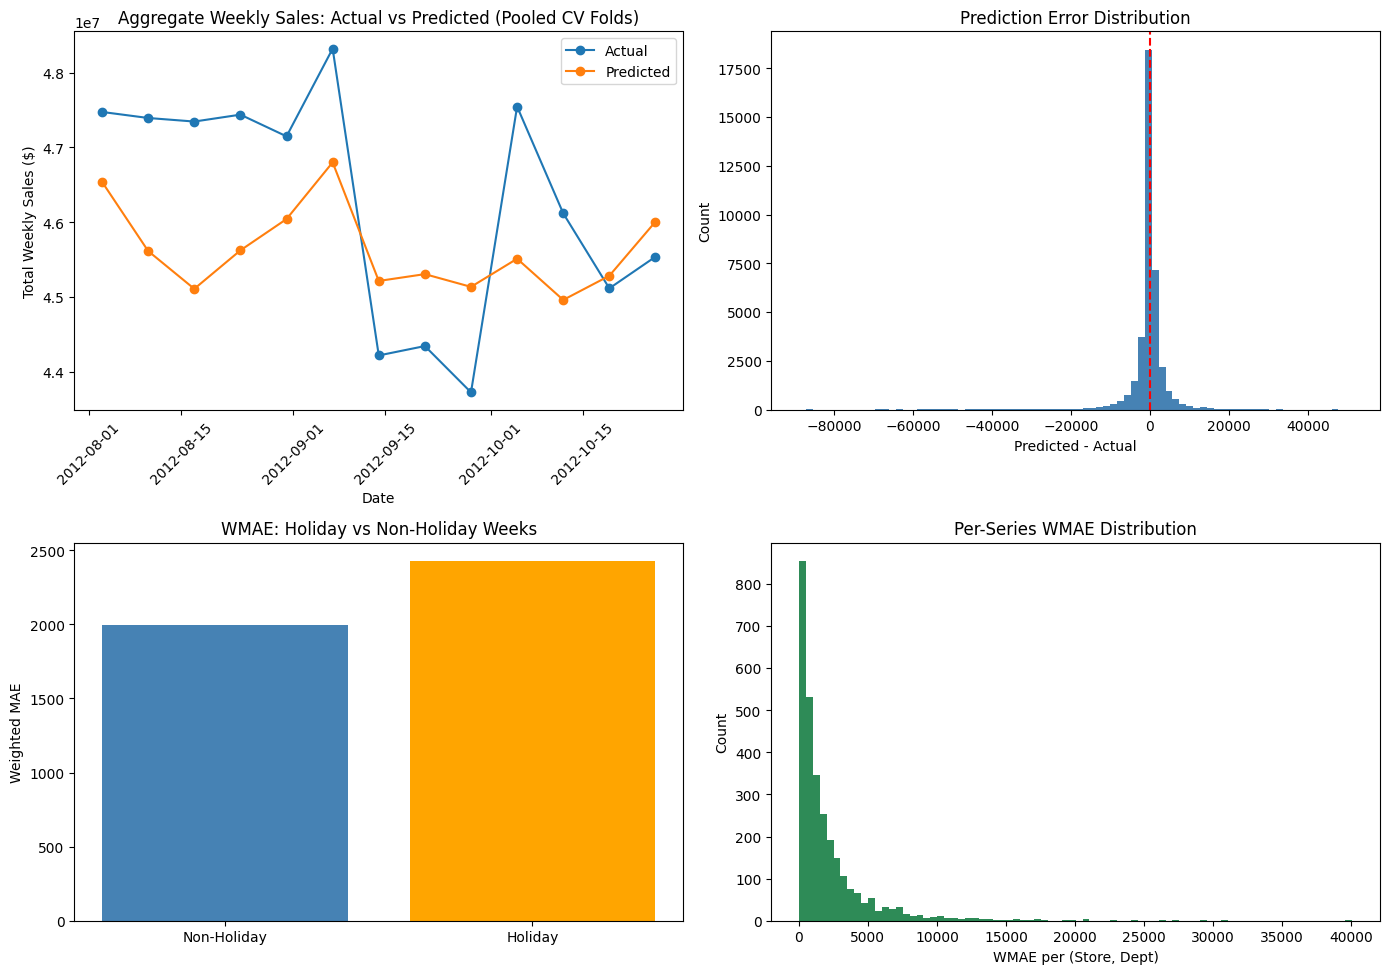

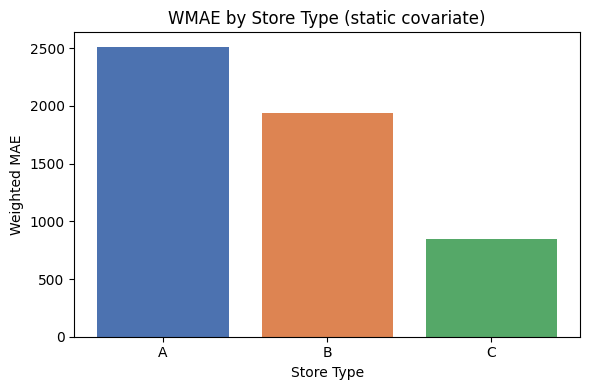

Top 10 worst-performing series (highest WMAE):
Store  Dept
13     3       40105.817498
35     72      30902.680074
27     3       29505.318566
14     3       27569.944026
19     3       26170.165236
16     9       26118.890560
17     92      24547.656258
28     92      24163.693018
35     3       22652.887957
14     92      21026.710232
dtype: float64

WMAE by store Type:
Type
A    2511.299892
B    1933.808040
C     844.340987
dtype: float64


In [16]:
scored["error"] = scored["Weekly_Sales_Pred"] - scored["Weekly_Sales"]
scored["abs_error"] = scored["error"].abs()
scored["weight"] = scored["IsHoliday"].map({True: 5, False: 1})
scored = scored.merge(stores_df[["Store", "Type"]], on="Store", how="left")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

agg = scored.groupby("Date")[["Weekly_Sales", "Weekly_Sales_Pred"]].sum().sort_index()
axes[0, 0].plot(agg.index, agg["Weekly_Sales"], label="Actual", marker="o")
axes[0, 0].plot(agg.index, agg["Weekly_Sales_Pred"], label="Predicted", marker="o")
axes[0, 0].set_title("Aggregate Weekly Sales: Actual vs Predicted (Pooled CV Folds)")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Total Weekly Sales ($)")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].hist(scored["error"], bins=80, color="steelblue")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_title("Prediction Error Distribution")
axes[0, 1].set_xlabel("Predicted - Actual")
axes[0, 1].set_ylabel("Count")

by_holiday = scored.groupby("IsHoliday")[["abs_error", "weight"]].apply(
    lambda g: (g["abs_error"] * g["weight"]).sum() / g["weight"].sum()
)
axes[1, 0].bar(["Non-Holiday", "Holiday"], by_holiday.values, color=["steelblue", "orange"])
axes[1, 0].set_title("WMAE: Holiday vs Non-Holiday Weeks")
axes[1, 0].set_ylabel("Weighted MAE")

def series_wmae(g):
    w = g["IsHoliday"].map({True: 5, False: 1})
    return (g["abs_error"] * w).sum() / w.sum()

per_series = scored.groupby(["Store", "Dept"])[["IsHoliday", "abs_error"]].apply(series_wmae).sort_values(ascending=False)
axes[1, 1].hist(per_series, bins=80, color="seagreen")
axes[1, 1].set_title("Per-Series WMAE Distribution")
axes[1, 1].set_xlabel("WMAE per (Store, Dept)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../submissions/_tft_diagnostics.png", dpi=120)
plt.show()

# TFT-only: WMAE by store Type, since Type is one of the static covariates
by_type = scored.groupby("Type")[["abs_error", "weight"]].apply(
    lambda g: (g["abs_error"] * g["weight"]).sum() / g["weight"].sum()
).sort_index()

plt.figure(figsize=(6, 4))
plt.bar(by_type.index.astype(str), by_type.values, color=["#4c72b0", "#dd8452", "#55a868"])
plt.title("WMAE by Store Type (static covariate)")
plt.xlabel("Store Type")
plt.ylabel("Weighted MAE")
plt.tight_layout()
plt.savefig("../submissions/_tft_wmae_by_type.png", dpi=120)
plt.show()

print("Top 10 worst-performing series (highest WMAE):")
print(per_series.head(10))
print("\nWMAE by store Type:")
print(by_type)


##  Representative-series forecast plots with quantile bands

Best- and worst-WMAE series from the diagnostics above, each showing
history, actual, the median (`q0.5`) forecast, and the 10-90% quantile band
from the probabilistic TFT output - a distinctive visual none of the other
DL models in this project can produce, since only TFT here uses
`QuantileRegression`.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 1.0 K  | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 860    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=4` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 1.0 K  | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 860    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=4` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

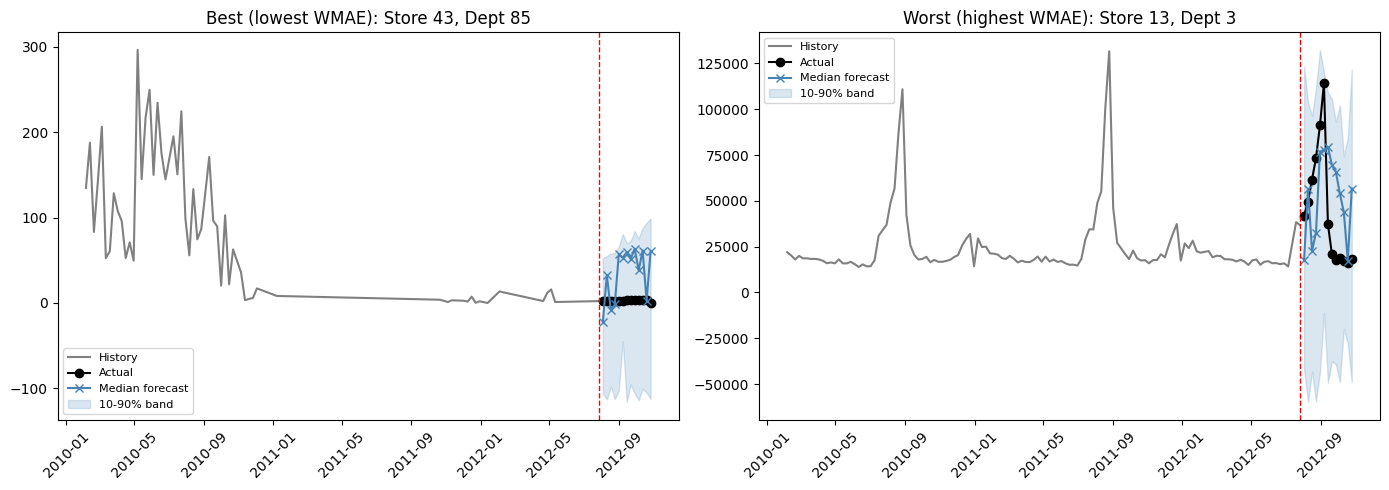

In [17]:
def plot_series_forecast(store, dept, split, ax, title_prefix):
    key = (store, dept)
    idx = series_keys.index(key)
    ts_full = target_series[idx]
    tr, va = split_series(ts_full, split)

    scaler = Scaler()
    tr_scaled = scaler.fit_transform(tr)
    cov = store_cov_series[store]
    past_cov, future_cov = split_past_future([cov], TFT_FUTURE_COLS, TFT_PAST_COLS)

    quick_model = TFTModel(
        n_epochs=CV_N_EPOCHS,
        batch_size=BATCH_SIZE_SEARCH,
        pl_trainer_kwargs=make_accelerator_kwargs(),
        **BEST_HP_KWARGS,
        **TFT_ARCH_KWARGS,
    )
    # Single series here, so max_samples_per_ts has little effect - kept for consistency.
    quick_model.fit(
        series=[tr_scaled],
        past_covariates=past_cov if SUPPORTS_PAST else None,
        future_covariates=future_cov if SUPPORTS_FUTURE else None,
        max_samples_per_ts=MAX_SAMPLES_PER_TS_CV,
    )
    pred_scaled = quick_model.predict(
        n=VAL_WEEKS,
        series=[tr_scaled],
        past_covariates=past_cov if SUPPORTS_PAST else None,
        future_covariates=future_cov if SUPPORTS_FUTURE else None,
        num_samples=NUM_SAMPLES_PREDICT,
    )[0]

    q10 = scaler.inverse_transform(pred_scaled.quantile(0.1))
    q50 = scaler.inverse_transform(pred_scaled.quantile(0.5))
    q90 = scaler.inverse_transform(pred_scaled.quantile(0.9))

    hist_df = tr.to_dataframe()
    actual_df = va.to_dataframe()
    dates_pred = q50.time_index

    ax.plot(hist_df.index, hist_df.iloc[:, 0], color="gray", label="History")
    ax.plot(actual_df.index, actual_df.iloc[:, 0], color="black", marker="o", label="Actual")
    ax.plot(dates_pred, q50.values().flatten(), color="steelblue", marker="x", label="Median forecast")
    ax.fill_between(dates_pred, q10.values().flatten(), q90.values().flatten(), color="steelblue", alpha=0.2, label="10-90% band")
    ax.axvline(tr.end_time(), color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{title_prefix}: Store {store}, Dept {dept}")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)


best_key = per_series.index[-1]
worst_key = per_series.index[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_series_forecast(best_key[0], best_key[1], splits[-1], axes[0], "Best (lowest WMAE)")
plot_series_forecast(worst_key[0], worst_key[1], splits[-1], axes[1], "Worst (highest WMAE)")
plt.tight_layout()
plt.savefig("../submissions/_tft_representative_forecasts.png", dpi=120)
plt.show()


##  Required `.predict()` wrapper (`DartsForecastPipeline`)

Per `CLAUDE.md`, every model needs a pipeline-shaped wrapper that takes raw,
unpreprocessed `test.csv`-shaped data and handles everything internally, so
`model_inference.ipynb` can call it directly. Extends the DLinear/N-BEATS
wrapper with static-covariate attachment (`attach_static_covariates`) and
returns the median (`q0.5`) quantile as the point forecast. Scales each
series with its own fitted `Scaler`, keyed by `(Store, Dept)` identity rather
than list position - darts' `Scaler` otherwise matches fitted params to
series by position, which breaks as soon as any series gets filtered out.

In [18]:
class DartsForecastPipeline:
    def __init__(self, darts_model, preprocessor, scaler_target_by_key, df_scaler,
                 numeric_cols, future_covariate_cols, past_covariate_cols,
                 all_covariate_cols, train_history_df, freq="W-FRI",
                 output_chunk_length=39, min_required_length=91, num_samples=50):
        self.darts_model = darts_model
        self.preprocessor = preprocessor
        self.scaler_target_by_key = scaler_target_by_key
        self.df_scaler = df_scaler
        self.numeric_cols = numeric_cols
        self.future_covariate_cols = future_covariate_cols
        self.past_covariate_cols = past_covariate_cols
        self.all_covariate_cols = all_covariate_cols
        self.train_history_df = train_history_df
        self.freq = freq
        self.output_chunk_length = output_chunk_length
        self.min_required_length = min_required_length
        self.num_samples = num_samples

    def predict(self, raw_test_df):
        test_clean = self.preprocessor.transform(raw_test_df)
        test_feat_local = add_temporal_features(test_clean)

        combined = pd.concat(
            [self.train_history_df, test_feat_local], ignore_index=True, sort=False
        ).drop_duplicates(subset=["Store", "Dept", "Date"])
        combined[self.numeric_cols] = self.df_scaler.transform(combined[self.numeric_cols])

        target_hist, _, keys = build_darts_series(
            self.train_history_df, value_col="Weekly_Sales", covariate_cols=[], freq=self.freq
        )
        target_hist = attach_static_covariates(target_hist, keys)
        # Scale each series with its own fitted scaler, keyed by (Store, Dept) identity
        # rather than list position - darts' Scaler otherwise matches fitted params to
        # series by position, which breaks as soon as any series gets filtered out below.
        target_hist_scaled = [
            self.scaler_target_by_key[key].transform(ts) for ts, key in zip(target_hist, keys)
        ]

        global_start = combined["Date"].min()
        global_end = combined["Date"].max()
        store_cov = build_store_level_covariates(
            combined, self.all_covariate_cols, global_start, global_end, freq=self.freq
        )

        filtered_target, filtered_cov, filtered_keys = [], [], []
        for tgt, key in zip(target_hist_scaled, keys):
            if len(tgt) >= self.min_required_length:
                filtered_target.append(tgt)
                filtered_cov.append(store_cov[key[0]])
                filtered_keys.append(key)

        past_cov = [ts[self.past_covariate_cols] for ts in filtered_cov] if self.past_covariate_cols else None
        future_cov = [ts[self.future_covariate_cols] for ts in filtered_cov] if self.future_covariate_cols else None

        preds_scaled = self.darts_model.predict(
            n=self.output_chunk_length,
            series=filtered_target,
            past_covariates=past_cov if self.darts_model.supports_past_covariates else None,
            future_covariates=future_cov if self.darts_model.supports_future_covariates else None,
            num_samples=self.num_samples,
        )
        preds_median_scaled = [ts.quantile(0.5) for ts in preds_scaled]
        # Inverse-transform each prediction with the scaler fitted for that exact
        # (Store, Dept) series - again by key, not by position in preds_scaled.
        preds = [
            self.scaler_target_by_key[key].inverse_transform(ts)
            for ts, key in zip(preds_median_scaled, filtered_keys)
        ]

        rows = []
        for (store, dept), ts in zip(filtered_keys, preds):
            df = ts.to_dataframe().reset_index()
            df.columns = ["Date", "Weekly_Sales"]
            df["Store"] = store
            df["Dept"] = dept
            rows.append(df)
        result = pd.concat(rows, ignore_index=True)

        result["Id"] = (
            result["Store"].astype(str) + "_" +
            result["Dept"].astype(str) + "_" +
            result["Date"].dt.strftime("%Y-%m-%d")
        )
        return result[["Id", "Weekly_Sales"]]


##  Final fit on full history and log `TFT_Final`

Refits on all available train data with a fresh model instance (never reuse
a model object whose `.fit()` already ran), using `BEST_HP_KWARGS` from the
hyperparameter search, wraps it, and logs the wrapper (not the bare darts
model) as the run artifact so `model_inference.ipynb` can load it directly.
A training-loss curve and the TFT interpretability plots (`TFTExplainer`)
are logged as artifacts on this run too.

In [19]:
scaler_target_by_key = {}
target_full_scaled = []
for tgt, key in zip(target_series, series_keys):
    sc = Scaler()
    target_full_scaled.append(sc.fit_transform(tgt))
    scaler_target_by_key[key] = sc

final_target, final_cov, final_keys = [], [], []
for tgt, key in zip(target_full_scaled, series_keys):
    if len(tgt) >= MIN_REQUIRED_LENGTH:
        final_target.append(tgt)
        final_cov.append(store_cov_series[key[0]])
        final_keys.append(key)

print(f"Original series: {len(target_full_scaled)}")
print(f"Filtered series for final fit: {len(final_target)}")
print(f"Dropped (too short for input+output chunk length): {len(target_full_scaled) - len(final_target)}")

past_full, future_full = split_past_future(final_cov, TFT_FUTURE_COLS, TFT_PAST_COLS)

n_nan_targets = sum(int(np.isnan(ts.values()).sum()) for ts in final_target)
n_nan_covs = sum(int(np.isnan(ts.values()).sum()) for ts in final_cov)
print(f"NaN count in target inputs: {n_nan_targets}")
print(f"NaN count in covariate inputs: {n_nan_covs}")
assert n_nan_targets == 0 and n_nan_covs == 0, "NaNs present in final fit inputs - stop"

final_csv_logger = CSVLogger(save_dir="../submissions/_tft_logs", name="final")
# Same BEST_HP_KWARGS as every CV fold - no early stopping (full history, no held-out val set).
final_model = TFTModel(
    n_epochs=FINAL_N_EPOCHS,
    batch_size=BATCH_SIZE_FINAL,
    pl_trainer_kwargs=make_accelerator_kwargs(logger=final_csv_logger),
    **BEST_HP_KWARGS,
    **TFT_ARCH_KWARGS,
)
final_model.fit(
    series=final_target,
    past_covariates=past_full if SUPPORTS_PAST else None,
    future_covariates=future_full if SUPPORTS_FUTURE else None,
    max_samples_per_ts=MAX_SAMPLES_PER_TS_FINAL,
)

pipeline = DartsForecastPipeline(
    darts_model=final_model,
    preprocessor=preprocessor,
    scaler_target_by_key=scaler_target_by_key,
    df_scaler=df_scaler,
    numeric_cols=numeric_cols,
    future_covariate_cols=TFT_FUTURE_COLS,
    past_covariate_cols=TFT_PAST_COLS,
    all_covariate_cols=all_covariate_cols,
    train_history_df=train_feat,
    freq=FREQ,
    output_chunk_length=OUTPUT_CHUNK_LENGTH,
    min_required_length=MIN_REQUIRED_LENGTH,
    num_samples=NUM_SAMPLES_PREDICT,
)

with mlflow.start_run(run_name="TFT_Final") as final_run:
    mlflow.log_params({
        "n_epochs": FINAL_N_EPOCHS,
        "batch_size": BATCH_SIZE_FINAL,
        "max_samples_per_ts": MAX_SAMPLES_PER_TS_FINAL,
        "num_samples_predict": NUM_SAMPLES_PREDICT,
        "future_covariates": ",".join(TFT_FUTURE_COLS) if TFT_FUTURE_COLS else "none",
        "past_covariates": ",".join(TFT_PAST_COLS),
        "static_covariates": "Type_Code,Size_Scaled,Store_Code,Dept_Code",
        "n_series_final": len(final_target),
        "cv_strategy": "expanding_window",
        "n_splits": N_SPLITS,
        "val_weeks": VAL_WEEKS,
        **BEST_HP_KWARGS,
        **{k: v for k, v in TFT_ARCH_KWARGS.items() if k not in ("likelihood", "categorical_embedding_sizes")},
    })
    mlflow.log_metric("cv_wmae_mean_at_selection", wmae_mean)
    mlflow.log_metric("cv_wmae_std_at_selection", wmae_std)
    mlflow.log_metric("cv_mae_mean_at_selection", mae_mean)

    try:
        final_loss_history = pd.read_csv(f"{final_csv_logger.log_dir}/metrics.csv")
        loss_curve = final_loss_history.dropna(subset=["train_loss"]) if "train_loss" in final_loss_history else None
        plt.figure(figsize=(6, 4))
        if loss_curve is not None and not loss_curve.empty:
            plt.plot(loss_curve["epoch"], loss_curve["train_loss"], marker="o", color="darkorange")
        plt.title("TFT Final - training loss")
        plt.xlabel("Epoch")
        plt.ylabel("Train loss")
        plt.tight_layout()
        plt.savefig("../submissions/_tft_final_train_loss.png", dpi=120)
        plt.close()
        mlflow.log_artifact("../submissions/_tft_final_train_loss.png")
    except Exception as e:
        print(f"Could not read/plot final loss history ({e})")

    try:
        # TFTExplainer requires an explicit background_series since final_model was
        # trained on many series (only optional for a single-series model) - use one
        # representative series (the same "best" one from the forecast-plot section
        # above, if it survived the final-fit length filter) plus its matching covariates.
        explain_idx = final_keys.index(best_key) if best_key in final_keys else 0
        background_series = [final_target[explain_idx]]
        background_past = [past_full[explain_idx]] if past_full else None
        background_future = [future_full[explain_idx]] if future_full else None

        explainer = TFTExplainer(
            final_model,
            background_series=background_series,
            background_past_covariates=background_past,
            background_future_covariates=background_future,
        )
        explain_result = explainer.explain()

        attn_fig = explainer.plot_attention(explain_result, plot_type="all", show_plot=False)
        if isinstance(attn_fig, list):
            attn_fig = attn_fig[0]
        attn_fig.savefig("../submissions/_tft_attention.png", dpi=120, bbox_inches="tight")
        plt.close(attn_fig)
        mlflow.log_artifact("../submissions/_tft_attention.png")

        vsn_fig = explainer.plot_variable_selection(explain_result, show_plot=False)
        if isinstance(vsn_fig, list):
            vsn_fig = vsn_fig[0]
        vsn_fig.savefig("../submissions/_tft_variable_selection.png", dpi=120, bbox_inches="tight")
        plt.close(vsn_fig)
        mlflow.log_artifact("../submissions/_tft_variable_selection.png")
        print("Logged TFTExplainer attention + variable-selection plots.")
    except Exception as e:
        print(f"TFTExplainer plots skipped ({e}) - not fatal, continuing.")

    with tempfile.TemporaryDirectory() as tmp:
        pkl_path = f"{tmp}/tft_pipeline.pkl"
        with open(pkl_path, "wb") as f:
            pickle.dump(pipeline, f)
        mlflow.log_artifact(pkl_path, artifact_path="pipeline")

    final_run_id = final_run.info.run_id

print("Logged TFT_Final wrapper artifact, run_id:", final_run_id)


Original series: 3331
Filtered series for final fit: 3123
Dropped (too short for input+output chunk length): 208


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 1.0 K  | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 860    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

NaN count in target inputs: 0
NaN count in covariate inputs: 0


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=8` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Logged TFTExplainer attention + variable-selection plots.
🏃 View run TFT_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6/runs/6729387124cd4baab722dca193d63175
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6
Logged TFT_Final wrapper artifact, run_id: 6729387124cd4baab722dca193d63175


##  Generate submission CSV

Reconciles against `sampleSubmission.csv` exactly - drops any predicted rows
beyond what's required, fills any missing ones (dropped short-history
series) with a store/dept mean fallback, so the row count and ID set match
precisely. Also pushes the submission CSV and the diagnostics PNGs to
MLflow as artifacts on `TFT_Final`.

In [20]:
submission = pipeline.predict(test_raw)

sample = pd.read_csv("../data/raw/sampleSubmission.csv")
required_ids = set(sample["Id"])

extra_ids = set(submission["Id"]) - required_ids
print("Extra rows generated beyond what's needed:", len(extra_ids))

submission_filtered = submission[submission["Id"].isin(required_ids)].copy()
missing_ids = required_ids - set(submission_filtered["Id"])
print("Still missing after filtering:", len(missing_ids))

fallback_lookup = train_feat.groupby(["Store", "Dept"])["Weekly_Sales"].mean().to_dict()
global_fallback = train_feat["Weekly_Sales"].mean()

missing_df = pd.DataFrame({"Id": sorted(missing_ids)})
parts = missing_df["Id"].str.rsplit("_", n=1, expand=True)
store_dept = parts[0].str.split("_", n=1, expand=True)
missing_df["Store"] = store_dept[0].astype(int)
missing_df["Dept"] = store_dept[1].astype(int)
missing_df["Weekly_Sales"] = missing_df.apply(
    lambda r: fallback_lookup.get((r["Store"], r["Dept"]), global_fallback), axis=1
)

final_submission = pd.concat(
    [submission_filtered, missing_df[["Id", "Weekly_Sales"]]], ignore_index=True
).sort_values("Id").reset_index(drop=True)

print("Final rows:", len(final_submission), "| Expected:", len(sample))
assert len(final_submission) == len(sample)
assert set(final_submission["Id"]) == required_ids

final_submission.to_csv("../submissions/tft_submission.csv", index=False)
final_submission.head()


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

Extra rows generated beyond what's needed: 8176
Still missing after filtering: 1443
Final rows: 115064 | Expected: 115064


,Id,Weekly_Sales
0,10_10_2012-11-02,47514.931431
1,10_10_2012-11-09,46542.268723
2,10_10_2012-11-16,47191.236594
3,10_10_2012-11-23,49008.504742
4,10_10_2012-11-30,44860.984985


In [21]:
with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("../submissions/tft_submission.csv")
    mlflow.log_artifact("../submissions/_tft_diagnostics.png")
    mlflow.log_artifact("../submissions/_tft_wmae_by_type.png")
    mlflow.log_artifact("../submissions/_tft_representative_forecasts.png")

print("Submission + diagnostics logged as artifacts on TFT_Final (run_id:", final_run_id, ")")


🏃 View run TFT_Final at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6/runs/6729387124cd4baab722dca193d63175
🧪 View experiment at: https://dagshub.com/NikaMikeltadze/walmart-sales-forecasting.mlflow/#/experiments/6
Submission + diagnostics logged as artifacts on TFT_Final (run_id: 6729387124cd4baab722dca193d63175 )
